First 5 Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Shape:
(891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Records:
0

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Survival Counts:
Survived
0    549
1    342
Name: count, dtype: int64


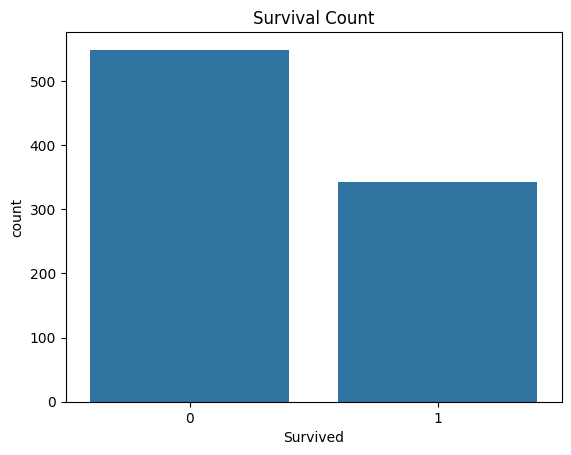


Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


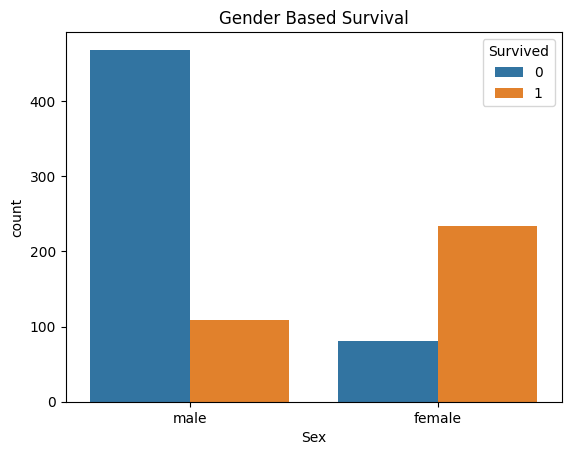

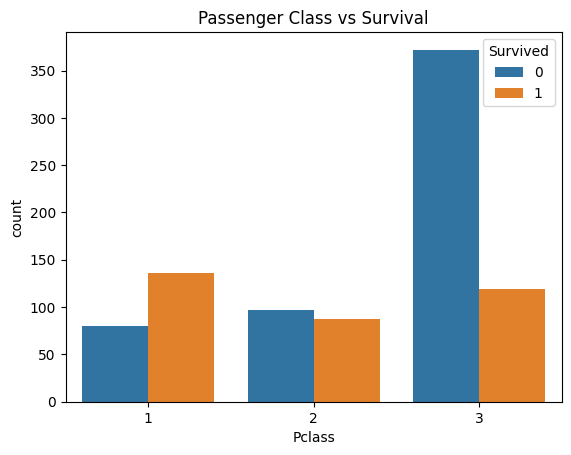

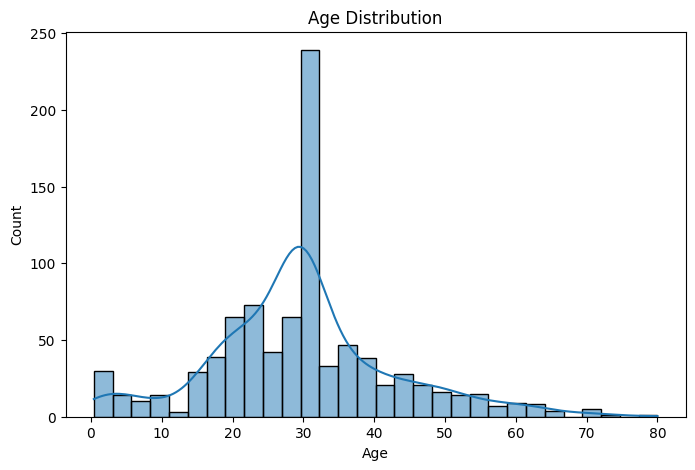

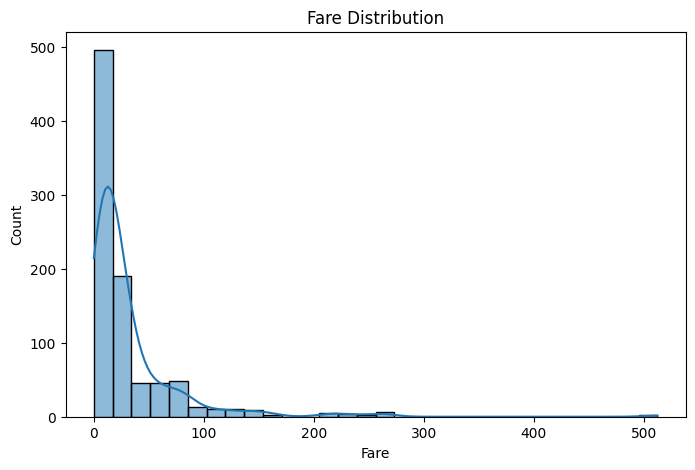

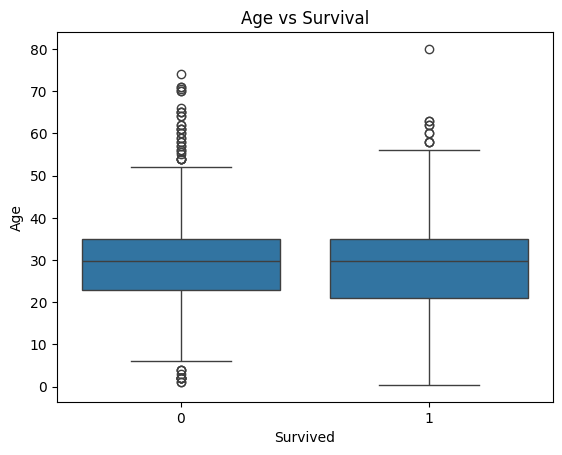

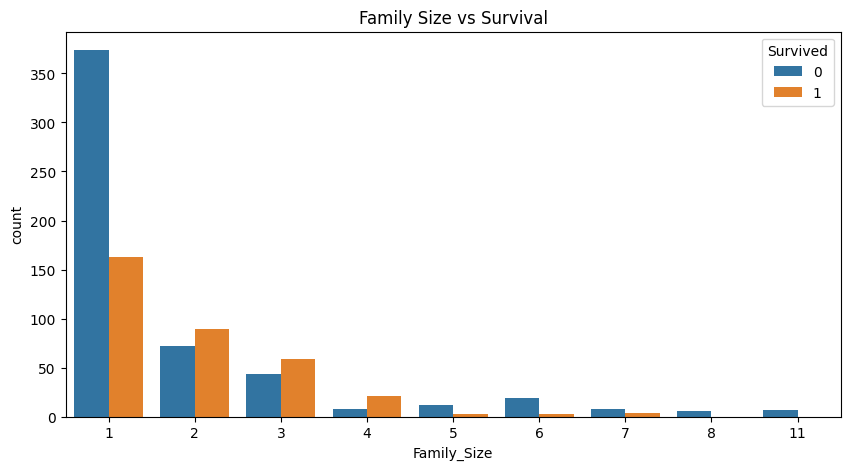

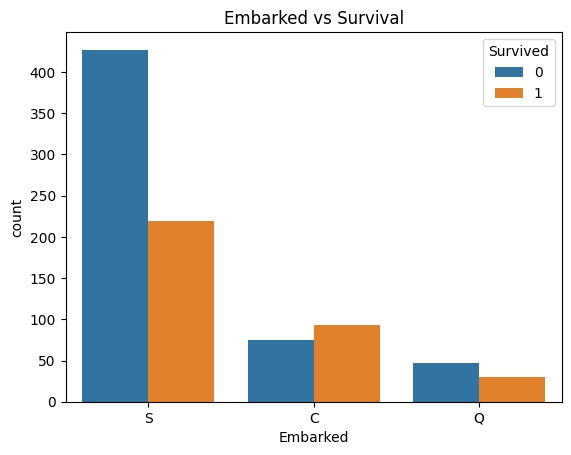

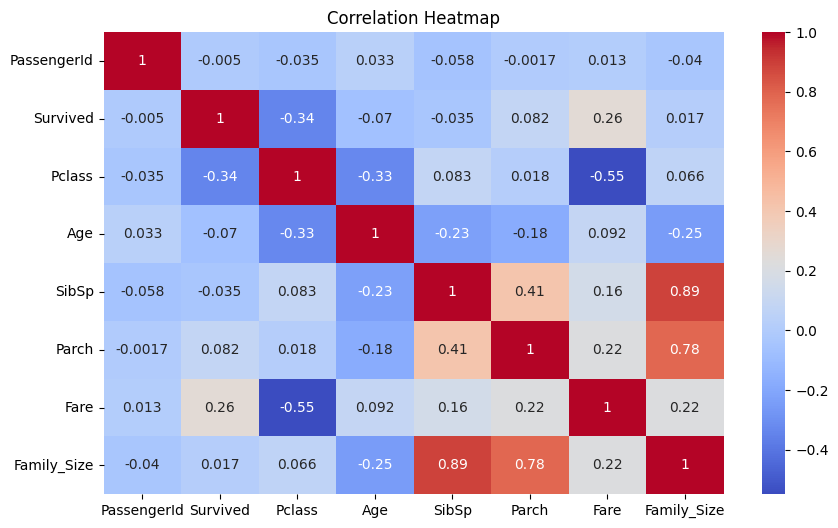

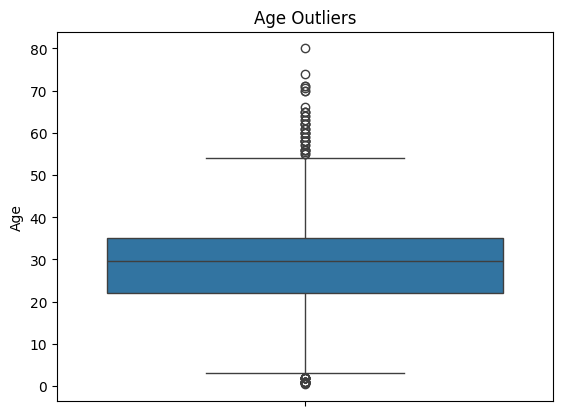

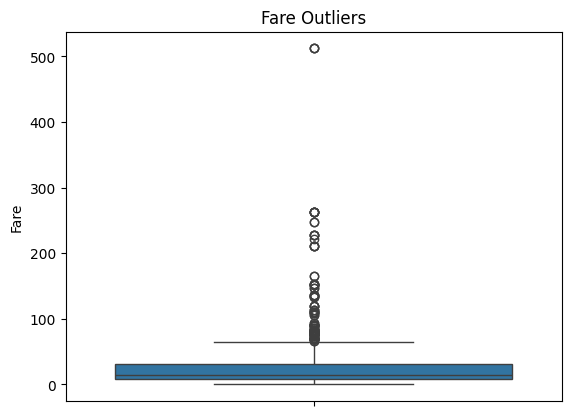


Final Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1



Titanic Dataset EDA Insights:

1. Dataset contains passenger details and survival information.
2. Missing values were cleaned successfully.
3. Female passengers had higher survival rates.
4. Passenger class significantly affected survival chances.
5. Age and Fare distributions were analyzed.
6. Family size influenced survival patterns.
7. Correlation analysis was performed.
8. Outliers were detected in Age and Fare.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

data = pd.read_csv("/content/train.csv")

print("First 5 Rows:")
display(data.head())

print("\nDataset Shape:")
print(data.shape)

print("\nColumns:")
print(data.columns)

print("\nDataset Info:")
data.info()

print("\nStatistical Summary:")
display(data.describe())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nDuplicate Records:")
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

if 'Cabin' in data.columns:
    data.drop('Cabin', axis=1, inplace=True)

print("\nMissing Values After Cleaning:")
print(data.isnull().sum())

print("\nSurvival Counts:")
print(data['Survived'].value_counts())

sns.countplot(x='Survived', data=data)
plt.title("Survival Count")
plt.show()

print("\nSurvival Percentage:")
print(data['Survived'].value_counts(normalize=True) * 100)

sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Gender Based Survival")
plt.show()

sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title("Passenger Class vs Survival")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

sns.boxplot(x='Survived', y='Age', data=data)
plt.title("Age vs Survival")
plt.show()

data['Family_Size'] = data['SibSp'] + data['Parch'] + 1

plt.figure(figsize=(10,5))
sns.countplot(x='Family_Size', hue='Survived', data=data)
plt.title("Family Size vs Survival")
plt.show()

sns.countplot(x='Embarked', hue='Survived', data=data)
plt.title("Embarked vs Survival")
plt.show()

numeric_data = data.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.boxplot(y=data['Age'])
plt.title("Age Outliers")
plt.show()

sns.boxplot(y=data['Fare'])
plt.title("Fare Outliers")
plt.show()

print("\nFinal Dataset:")
display(data.head())

print("""
Titanic Dataset EDA Insights:

1. Dataset contains passenger details and survival information.
2. Missing values were cleaned successfully.
3. Female passengers had higher survival rates.
4. Passenger class significantly affected survival chances.
5. Age and Fare distributions were analyzed.
6. Family size influenced survival patterns.
7. Correlation analysis was performed.
8. Outliers were detected in Age and Fare.
""")